In [6]:
%matplotlib inline
import sys
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage

ROOT = Path("/run/media/gabriele/discone/Files/Magistrale/TESI/Codice") # Path("/home/gmaggi/Documents/Magistrale/Tesi/Codice")
sys.path.insert(0, str(ROOT / "Tests"))

from thesis_lib_shared.io import read_mat_image, read_dng_image
from thesis_lib_shared.metrics import sift_keypoint_matches, rgb_to_lab, delta_e_images, delta_e_summary


In [28]:
PAIRED = ROOT / "data/iphone2samsung_or/pair-np-dv/paired"
print(PAIRED / "iphone-x/dng/00.mat")

img_a = read_mat_image(PAIRED / "iphone-x/dng/03.mat")
img_b = read_mat_image(PAIRED / "samsung-s9/dng/03.mat")

img_a_orig = img_a
img_b_orig = img_b

h_orig, w_orig = img_a_orig.shape[:2]

resize_p=0.7
h_a, w_a = img_a.shape[:2]
new_w, new_h = int(w_a * resize_p), int(h_a * resize_p)

img_b = cv2.resize(img_b_orig, (new_w, new_h))
img_a = cv2.resize(img_a_orig, (new_w, new_h))




/run/media/gabriele/discone/Files/Magistrale/TESI/Codice/data/iphone2samsung_or/pair-np-dv/paired/iphone-x/dng/00.mat


In [29]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(img_a)
axes[0].set_title(f"iPhone X (A) {img_a.shape}")
axes[0].axis("off")
axes[1].imshow(img_b)
axes[1].set_title(f"Samsung S9 (B) {img_b.shape}")
axes[1].axis("off")
plt.tight_layout()
plt.show()

/tmp/ipykernel_27871/688933320.py:9: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [30]:
kps_a, kps_b = sift_keypoint_matches(img_a, img_b, use_ransac=True)
print(f"{len(kps_a)} matched keypoints")

h = max(img_a.shape[0], img_b.shape[0])
canvas = np.zeros((h, img_a.shape[1] + img_b.shape[1], 3), dtype=np.float32)
canvas[: img_a.shape[0], : img_a.shape[1]] = img_a
canvas[: img_b.shape[0], img_a.shape[1] :] = img_b

plt.figure(figsize=(18, 8))
plt.imshow(canvas)
for (ra, ca), (rb, cb) in zip(kps_a[::5], kps_b[::5]):  
    plt.plot([ca, cb + img_a.shape[1]], [ra, rb], lw=0.5)
plt.title(f"AKAZE matches: {len(kps_a)} (showing 1/5)")
plt.axis("off")
plt.show()

288 matched keypoints


/tmp/ipykernel_27871/3762931860.py:15: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## 3. Homography estimation and alignment (warp B onto A)

In [31]:
def resize_function(img_a, img_b, img_b_aligned=None, H_mat=None, resize_p=0.1):
    h_a, w_a = img_a.shape[:2]
    new_w, new_h = int(w_a * resize_p), int(h_a * resize_p)

    img_a = cv2.resize(img_a, (new_w, new_h))
    img_b = cv2.resize(img_b, (new_w, new_h))
    img_b_aligned = cv2.resize(img_b_aligned, (new_w, new_h))

    valid_mask = cv2.warpPerspective(
        np.ones((h_a, w_a), dtype=np.float32), H_mat, (w_a, h_a)
    )
    valid_mask = cv2.resize(valid_mask, (new_w, new_h)) > 0.999

    return img_a, img_b, img_b_aligned, valid_mask

In [32]:
# Keypoints are (row, col) → OpenCV wants (x, y)
pts_a = kps_a[:, ::-1].astype(np.float32)
pts_b = kps_b[:, ::-1].astype(np.float32)

H_mat, inlier_mask = cv2.findHomography(pts_b, pts_a, cv2.RANSAC, 1.0)
print(f"Homography inliers: {int(inlier_mask.sum())} / {len(pts_b)}")

h_a, w_a = img_a.shape[:2]
img_b_aligned = cv2.warpPerspective(img_b, H_mat, (w_a, h_a))

valid_mask = cv2.warpPerspective(
    np.ones(img_b.shape[:2], dtype=np.float32), H_mat, (w_a, h_a)
) > 0.999

gray_a = cv2.cvtColor(img_a, cv2.COLOR_RGB2GRAY)
gray_b_aligned = cv2.cvtColor(img_b_aligned, cv2.COLOR_RGB2GRAY)

tile = 128
yy, xx = np.mgrid[:h_a, :w_a]
checker = ((yy // tile + xx // tile) % 2).astype(bool)
check_img = np.where(checker, gray_a, gray_b_aligned)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(check_img * valid_mask, cmap="gray")
axes[0].set_title("Checkerboard A / B-aligned (grayscale)")
axes[0].axis("off")
axes[1].imshow(np.abs(gray_a.astype(np.float32) - gray_b_aligned.astype(np.float32)) * valid_mask, cmap="gray")
axes[1].set_title("|A − B aligned| (grayscale)")
axes[1].axis("off")
plt.tight_layout()
plt.show()

Homography inliers: 172 / 288


/tmp/ipykernel_27871/3488384996.py:31: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [33]:
RESIZE_P = 1
img_a, img_b, img_b_aligned, valid_mask = resize_function(img_a=img_a, img_b=img_b, img_b_aligned=img_b_aligned, H_mat=H_mat, resize_p=RESIZE_P)

In [ ]:
# Optical flow between the aligned pair (residual motion left after the homography warp)
gray_a_flow = cv2.cvtColor(img_a, cv2.COLOR_RGB2GRAY)
gray_b_aligned_flow = cv2.cvtColor(img_b_aligned, cv2.COLOR_RGB2GRAY)

# Histogram-equalize both grayscale images before flow estimation: the two cameras
# have different exposure/tone curves, which biases Farneback's brightness-constancy
# assumption. Equalization needs uint8 input, then convert back to float32.
gray_a_u8 = (np.clip(gray_a_flow, 0.0, 1.0) * 255).astype(np.uint8)
gray_b_u8 = (np.clip(gray_b_aligned_flow, 0.0, 1.0) * 255).astype(np.uint8)
gray_a_eq = cv2.equalizeHist(gray_a_u8).astype(np.float32) / 255.0
gray_b_eq = cv2.equalizeHist(gray_b_u8).astype(np.float32) / 255.0



# Plain grayscale absolute difference between A and B-aligned, after histogram
# equalization, so you can see the residual shift directly
plt.figure(figsize=(8, 6))
plt.imshow(np.abs(gray_a_eq - gray_b_eq) * valid_mask, cmap="gray")
plt.title("|A − B-aligned| (grayscale, equalized)")
plt.axis("off")
plt.show()

/tmp/ipykernel_27871/2766612710.py:21: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


: 

Kept 120634 / 253576 valid pixels (44.1% of image)


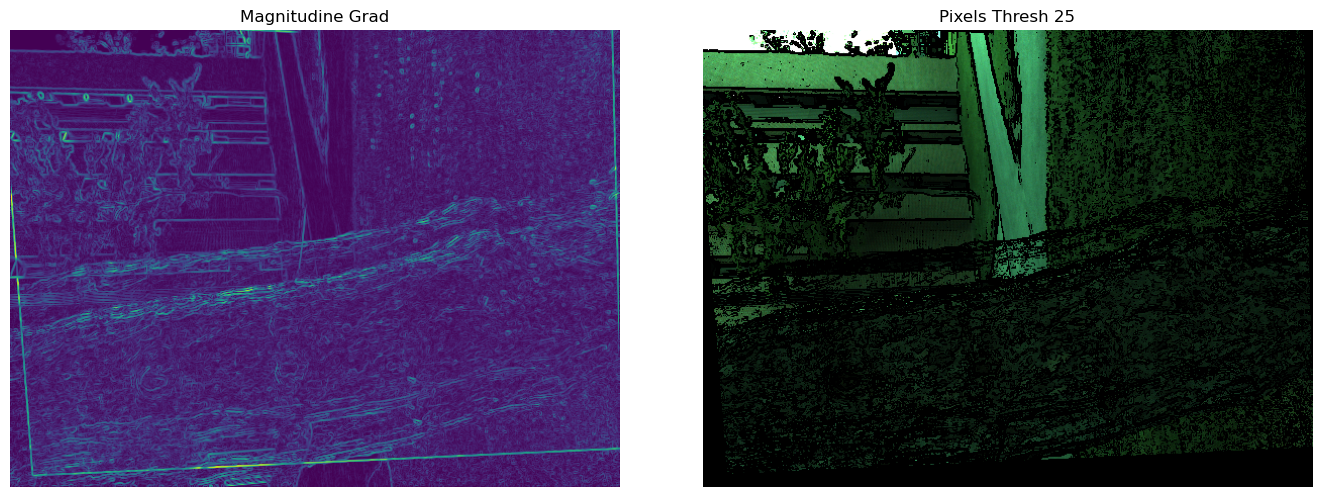

In [13]:
GRAD_THRESHOLD = 25  # on L* (0–100 scale) Sobel magnitude

def gradient_magnitude(img: np.ndarray) -> np.ndarray:
    l_channel = rgb_to_lab(img)[:, :, 0].astype(np.float32)
    gx = cv2.Sobel(l_channel, cv2.CV_32F, 1, 0, ksize=3)
    gy = cv2.Sobel(l_channel, cv2.CV_32F, 0, 1, ksize=3)
    return np.sqrt(gx**2 + gy**2)

grad = np.maximum(gradient_magnitude(img_a), gradient_magnitude(img_b_aligned))

keep_mask = (grad < GRAD_THRESHOLD) & valid_mask

print(f"Kept {keep_mask.sum()} / {valid_mask.sum()} valid pixels "
      f"({100 * keep_mask.mean():.1f}% of image)")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(grad, cmap="viridis")
axes[0].set_title("Magnitudine Grad")
axes[0].axis("off")
overlay = img_a.copy()
overlay[~keep_mask] *= 0
axes[1].imshow(overlay)
axes[1].set_title(f"Pixels Thresh {GRAD_THRESHOLD}")
axes[1].axis("off")
plt.tight_layout()
plt.show()

ΔE flat pixels only: {'mean': '7.272', 'std': '4.425', 'median': '6.311', 'p5': '2.759', 'p25': '4.858', 'p75': '8.321', 'p95': '15.426', 'min': '0.000', 'max': '55.340', 'n': '120634.000'}
ΔE all valid px:     {'mean': '8.290', 'std': '5.293', 'median': '6.857', 'p5': '3.053', 'p25': '5.132', 'p75': '9.731', 'p95': '18.876', 'min': '0.000', 'max': '61.037', 'n': '253576.000'}


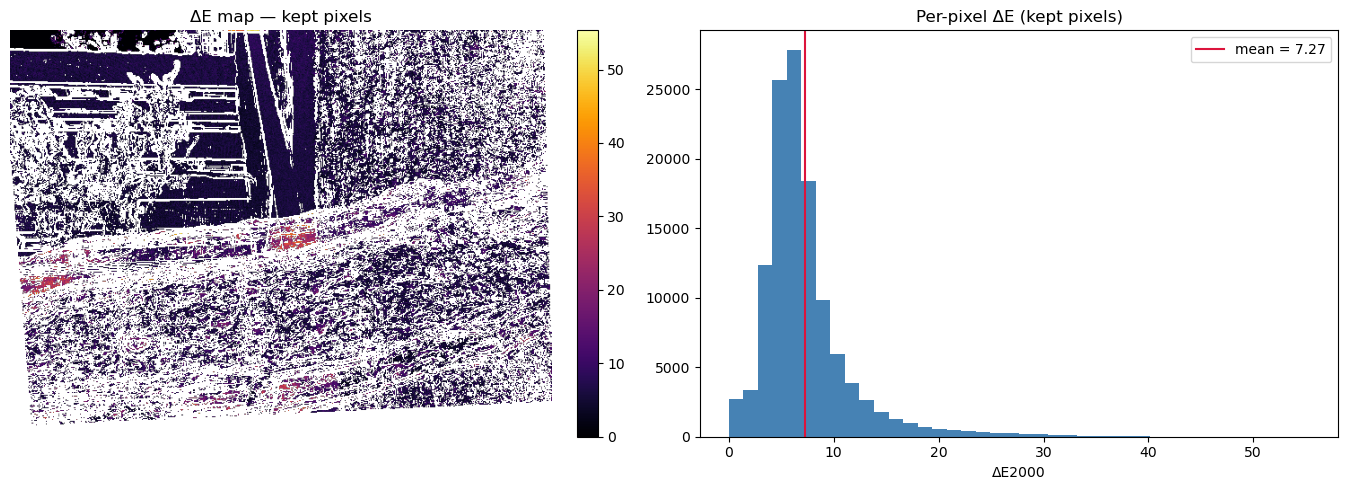

In [14]:
de_map = delta_e_images(img_a, img_b_aligned)

stats_kept = delta_e_summary(de_map[keep_mask])
stats_all = delta_e_summary(de_map[valid_mask])
print("ΔE flat pixels only:", {k: f"{v:.3f}" for k, v in stats_kept.items()})
print("ΔE all valid px:    ", {k: f"{v:.3f}" for k, v in stats_all.items()})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
de_show = np.where(keep_mask, de_map, np.nan)
im = axes[0].imshow(de_show, cmap="inferno", vmin=0)
axes[0].set_title("ΔE map — kept pixels")
axes[0].axis("off")
plt.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)
axes[1].hist(de_map[keep_mask], bins=40, color="steelblue")
axes[1].axvline(stats_kept["mean"], color="crimson", label=f"mean = {stats_kept['mean']:.2f}")
axes[1].set_title("Per-pixel ΔE (kept pixels)")
axes[1].set_xlabel("ΔE2000")
axes[1].legend()
plt.tight_layout()
plt.show()

In [15]:
sys.path.insert(0, str(ROOT / "Standard"))
from standard.metrics.metrics import compute_sift_delta_e

sift_stats = compute_sift_delta_e(img_a, img_b_aligned, patch_size=5)
print("SIFT eval (A vs B aligned):")
for k, v in sift_stats.items():
    print(f"  {k:18s} {v:.4f}")

sift_stats_aligned = compute_sift_delta_e(img_a, img_b_aligned, patch_size=16)
print("\nSIFT eval (A vs B aligned, patch_size=16):")
for k, v in sift_stats_aligned.items():
    print(f"  {k:18s} {v:.4f}")

SIFT eval (A vs B aligned):
  sift_delta_e       4.7571
  sift_delta_e_max   6.9861
  sift_delta_e_min   0.0000
  sift_n_matches     77.0000
  psnr               22.5881
  ssim               0.4975

SIFT eval (A vs B aligned, patch_size=16):
  sift_delta_e       4.7456
  sift_delta_e_max   6.6352
  sift_delta_e_min   1.1335
  sift_n_matches     77.0000
  psnr               22.5881
  ssim               0.4975


In [16]:
H_inv = np.linalg.inv(H_mat)

NOISE_STD = 0.05  
rng = np.random.default_rng(42)
H_noise = 1.0 + rng.normal(0.0, NOISE_STD, size=H_inv.shape)
H_inv = H_inv * H_noise
H_inv /= H_inv[2, 2]  
img_a_distorted = cv2.warpPerspective(img_a_orig, H_inv, (w_orig, h_orig))

synth_valid_mask_full = cv2.warpPerspective(
    np.ones((h_orig, w_orig), dtype=np.float32), H_inv, (w_orig, h_orig)
) > 0.999

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(img_a_orig)
axes[0].set_title(f"iPhone original (A) {img_a_orig.shape}")
axes[0].axis("off")
axes[1].imshow(img_a_distorted)
axes[1].set_title("iPhone synthetic distorted view (A warped by noisy H⁻¹)")
axes[1].axis("off")
plt.tight_layout()
plt.show()

/tmp/ipykernel_27871/2828420759.py:22: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [17]:
# AKAZE keypoint matching: original iPhone view vs synthetic distorted view
kps_a2, kps_b2 = sift_keypoint_matches(img_a_orig, img_a_distorted, use_ransac=True)
print(f"{len(kps_a2)} matched keypoints")

h2 = max(img_a_orig.shape[0], img_a_distorted.shape[0])
canvas2 = np.zeros((h2, img_a_orig.shape[1] + img_a_distorted.shape[1], 3), dtype=np.float32)
canvas2[: img_a_orig.shape[0], : img_a_orig.shape[1]] = img_a_orig
canvas2[: img_a_distorted.shape[0], img_a_orig.shape[1] :] = img_a_distorted

plt.figure(figsize=(18, 8))
plt.imshow(canvas2)
for (ra, ca), (rb, cb) in zip(kps_a2[::5], kps_b2[::5]):
    plt.plot([ca, cb + img_a_orig.shape[1]], [ra, rb], lw=0.5)
plt.title(f"AKAZE matches (A vs A-distorted): {len(kps_a2)} (showing 1/5)")
plt.axis("off")
plt.show()

3528 matched keypoints


/tmp/ipykernel_27871/307672345.py:16: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [19]:
# Re-estimate homography from the matched keypoints and align A-distorted onto A
pts_a2 = kps_a2[:, ::-1].astype(np.float32)
pts_b2 = kps_b2[:, ::-1].astype(np.float32)

H_mat2, inlier_mask2 = cv2.findHomography(pts_b2, pts_a2, cv2.RANSAC, 1.0)
print(f"Homography inliers: {int(inlier_mask2.sum())} / {len(pts_b2)}")

h_a2, w_a2 = img_a.shape[:2]
img_a_distorted_aligned = cv2.warpPerspective(img_a_distorted, H_mat2, (w_a2, h_a2))

valid_mask2_full = cv2.warpPerspective(
    np.ones((h_a2, w_a2), dtype=np.float32), H_mat2, (w_a2, h_a2)
) > 0.999

# Checkerboard visualization, shown in grayscale
gray_a2 = cv2.cvtColor(img_a, cv2.COLOR_RGB2GRAY)
gray_a_distorted_aligned = cv2.cvtColor(img_a_distorted_aligned, cv2.COLOR_RGB2GRAY)

tile = 128
yy2, xx2 = np.mgrid[:h_a2, :w_a2]
checker2 = ((yy2 // tile + xx2 // tile) % 2).astype(bool)
check_img2 = np.where(checker2, gray_a2, gray_a_distorted_aligned)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(check_img2, cmap="gray")
axes[0].set_title("Checkerboard A / A-distorted-aligned (grayscale)")
axes[0].axis("off")
axes[1].imshow(np.abs(gray_a2.astype(np.float32) - gray_a_distorted_aligned.astype(np.float32)) * valid_mask, cmap="gray")
axes[1].set_title("|A − A-distorted-aligned| (grayscale)")
axes[1].axis("off")
plt.tight_layout()
plt.show()

Homography inliers: 3493 / 3528


/tmp/ipykernel_27871/1871825840.py:32: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [22]:
RES = 1
new_size2 = (int(round(w_a2 * RES)), int(round(h_a2 * RES)))
img_a2_small = cv2.resize(img_a_orig, new_size2, interpolation=cv2.INTER_AREA)
img_a_distorted_aligned_small = cv2.resize(img_a_distorted_aligned, new_size2, interpolation=cv2.INTER_AREA)
valid_mask2 = cv2.resize(
    valid_mask2_full.astype(np.float32), new_size2, interpolation=cv2.INTER_NEAREST
) > 0.999

In [23]:
grad2 = np.maximum(gradient_magnitude(img_a2_small), gradient_magnitude(img_a_distorted_aligned_small))

keep_mask2 = (grad2 < GRAD_THRESHOLD) & valid_mask2

print(f"Kept {keep_mask2.sum()} / {valid_mask2.sum()} valid pixels "
      f"({100 * keep_mask2.mean():.1f}% of image)")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(grad2, cmap="viridis")
axes[0].set_title("Magnitudine Grad (synthetic pair)")
axes[0].axis("off")
overlay2 = img_a2_small.copy()
overlay2[~keep_mask2] *= 0
axes[1].imshow(overlay2)
axes[1].set_title(f"Pixels Thresh {GRAD_THRESHOLD} (synthetic pair)")
axes[1].axis("off")
plt.tight_layout()
plt.show()

Kept 148209 / 264124 valid pixels (54.2% of image)


/tmp/ipykernel_27871/578126115.py:18: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [24]:
de_map2 = delta_e_images(img_a2_small, img_a_distorted_aligned_small)

stats_kept2 = delta_e_summary(de_map2[keep_mask2])
stats_all2 = delta_e_summary(de_map2[valid_mask2])
print("ΔE flat pixels only (synthetic, same-camera):", {k: f"{v:.3f}" for k, v in stats_kept2.items()})
print("ΔE all valid px (synthetic, same-camera):    ", {k: f"{v:.3f}" for k, v in stats_all2.items()})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
de_show2 = np.where(keep_mask2, de_map2, np.nan)
im2 = axes[0].imshow(de_show2, cmap="inferno", vmin=0)
axes[0].set_title("ΔE map — kept pixels (synthetic pair)")
axes[0].axis("off")
plt.colorbar(im2, ax=axes[0], fraction=0.046, pad=0.04)
axes[1].hist(de_map2[keep_mask2], bins=40, color="steelblue")
axes[1].axvline(stats_kept2["mean"], color="crimson", label=f"mean = {stats_kept2['mean']:.2f}")
axes[1].set_title("Per-pixel ΔE (kept pixels, synthetic pair)")
axes[1].set_xlabel("ΔE2000")
axes[1].legend()
plt.tight_layout()
plt.show()

ΔE flat pixels only (synthetic, same-camera): {'mean': '21.940', 'std': '12.229', 'median': '21.935', 'p5': '4.513', 'p25': '11.836', 'p75': '28.807', 'p95': '44.925', 'min': '0.000', 'max': '75.758', 'n': '148209.000'}
ΔE all valid px (synthetic, same-camera):     {'mean': '21.580', 'std': '12.322', 'median': '20.905', 'p5': '4.528', 'p25': '11.470', 'p75': '28.771', 'p95': '44.872', 'min': '0.000', 'max': '75.758', 'n': '264124.000'}


/tmp/ipykernel_27871/3405975215.py:20: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()
